In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from scipy.optimize import curve_fit

# ---- STILE PAPER ----
mpl.rcParams.update({

    # Usa font LaTeX (coerente con paper)
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],

    # Dimensioni testo (standard journal)
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Spessori ottimizzati per stampa
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # Tick dentro (stile PRL/JCP)
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    # Griglia molto leggera
    "grid.linestyle": ":",
    "grid.linewidth": 0.4,
    "grid.alpha": 0.5,

    # Legenda minimale
    "legend.frameon": False,
})

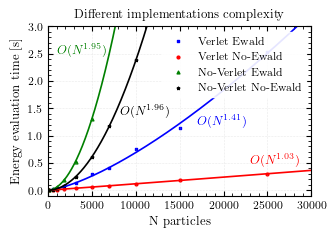

In [53]:
def power_law(n, C, alpha):
    return C * n**alpha

x = np.linspace(0,30000, 10000)

fig, ax = plt.subplots(figsize=(3.4, 2.2))

data_2 = np.loadtxt(f"./verlet_coul.csv", delimiter=";")

popt, pcov = curve_fit(power_law, data_2[:,0],data_2[:,1])
C, alpha = popt

plt.scatter(data_2[:,0],data_2[:,1],c="b", label=rf"Verlet Ewald",marker='s', s=4)
plt.plot(x, C*x**alpha, c ="b")
ax.text(17000, 1.2, rf"$O(N^{{ {alpha:.2f} }})$",c ="b")

data_1 = np.loadtxt(f"./verlet_no_coul.csv", delimiter=";")

popt, pcov = curve_fit(power_law, data_1[:,0],data_1[:,1])
C, alpha = popt

plt.scatter(data_1[:,0],data_1[:,1], c="r", label=rf"Verlet No-Ewald", marker='o', s=4)
plt.plot(x, C*x**alpha, c ="r")
ax.text(23000, 0.5, rf"$O(N^{{ {alpha:.2f} }})$",c ="r")


data_3 = np.loadtxt(f"./no_verlet_coul.csv", delimiter=";")

popt, pcov = curve_fit(power_law, data_3[:,0],data_3[:,1])
C, alpha = popt

plt.scatter(data_3[:,0],data_3[:,1],c="g", label=rf"No-Verlet Ewald",marker='^', s=4)
plt.plot(x, C*x**alpha, c ="g")
ax.text(1000, 2.5, rf"$O(N^{{ {alpha:.2f} }})$",c ="g")

data_4 = np.loadtxt(f"./no_verlet_no_coul.csv", delimiter=";")

popt, pcov = curve_fit(power_law, data_4[:,0],data_4[:,1])
C, alpha = popt

plt.scatter(data_4[:,0],data_4[:,1],c="k", label=rf"No-Verlet No-Ewald", marker='*', s=4)
plt.plot(x, C*x**alpha, c ="k")
ax.text(8200, 1.4, rf"$O(N^{{ {alpha:.2f} }})$",c ="k")

plt.xlabel("N particles")
plt.ylabel("Energy evaluation time [s]")

plt.title("Different implementations complexity")

plt.ylim([-0.1,3])
plt.xlim([0,30000])
plt.legend(
    loc="upper right",
    frameon=True,        # attiva il box
    facecolor="white",   # sfondo bianco
    edgecolor="white",   # bordo (opzionale)
    framealpha=0.9         # opacità piena
    )

plt.grid()
plt.minorticks_on()

plt.savefig("complexity_styled.pdf", bbox_inches="tight")
plt.show()